In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [22]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [23]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [24]:
df["fecha"].describe()

count                               77
mean     2025-03-01 19:19:28.831168768
min                2025-01-06 00:00:00
25%                2025-01-31 00:00:00
50%                2025-02-27 00:00:00
75%                2025-03-31 00:00:00
max                2025-04-30 00:00:00
Name: fecha, dtype: object

In [25]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [26]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [27]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
base_monetaria_std20,0,0.0
act_luis_caputo_prop_no_cero_lag1,0,0.0
merval_maximo_pct10,0,0.0
base_monetaria_diff10,0,0.0
...,...,...
bonos_soberanos_mean,0,0.0
act_desconocido_std_lag1,0,0.0
tc_mayorista_pct1,0,0.0
menciona_sector_industrial_prop_true_lag1,0,0.0


In [28]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [29]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [30]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(61, 60)
(16, 60)


## Funcion objetivo para Optuna y Cross-Validation

In [31]:
max_lag = 5 # por el moving average 5

In [32]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~63 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: mayor learning rate con pocos datos para evitar sobreajuste
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3, log=True),

        # Complejidad del árbol: REDUCIDA para evitar overfitting
        "num_leaves": trial.suggest_int("num_leaves", 5, 15),  # Mucho más simple
        "max_depth": trial.suggest_int("max_depth", 2, 4),  # Árboles poco profundos

        # Mínimos ajustados a dataset pequeño
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 10),  # Menor con pocos datos

        # Regularizaciones L1/L2 - MÁS FUERTES para evitar overfitting
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 20.0, log=True),

        # min_split_gain más alto para evitar splits innecesarios
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),

        # Submuestreo: menos agresivo con pocos datos
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),  # Feature sampling importante

        # MENOS árboles con dataset pequeño
        "n_estimators": trial.suggest_int("n_estimators", 20, 150),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con MENOS splits para dataset pequeño
    n_splits = 3  # Solo 3 folds con 63 filas
    test_size = 8  # ~2 semanas de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]  # Menos rounds
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [33]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=30, show_progress_bar=True)  # Reducido de 50 a 30 trials

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-15 12:17:09,777] A new study created in memory with name: lgbm_merval


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[I 2025-11-15 12:17:09,849] Trial 0 finished with value: 9729.75721896599 and parameters: {'learning_rate': 0.09856272650091137, 'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 10, 'lambda_l1': 2.8418399554232763, 'lambda_l2': 17.57752891268358, 'min_split_gain': 0.5411477666620612, 'subsample': 0.7218231647656206, 'colsample_bytree': 0.5191126487517222, 'n_estimators': 126}. Best is trial 0 with value: 9729.75721896599.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-15 12:17:11,220] Trial 23 finished with value: 9740.246389230846 and parameters: {'learning_rate': 0.06012316916369861, 'num_leaves': 12, 'max_depth': 3, 'min_child_samples': 7, 'lambda_l1': 0.17116925633235472, 'lambda_l2': 1.7334072495063528, 'min_split_gain': 1.9996211402755908, 'subsample': 0.962767551900525, 'colsample_bytree': 0.7949664889560374, 'n_estimators': 150}. Best is trial 13 with value: 8895.070489954907.
[I 2025-11-15 12:17:11,298] Trial 24 finished with value: 10297.620450568511 and parameters: {'learning_rate': 0.07790485708148792, 'num_leaves': 14, 'max_depth': 3, 'min_child_samples': 6, 'lambda_l1': 0.2172470112006982, 'lambda_l2': 0.5717017941279819, 'min_split_gain': 1.7939021277757403, 'subsample': 0.9174111268070151, 'colsample_bytree': 0.8597998418310544, 'n_estimators': 125}. Best is trial 13 with value: 8895.070489954907.
[I 2025-11-15 12:17:11,374] Trial 25 finished with value: 9622.732740408981 and parameters: {'learning_rate': 0.050033953020338

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 12:17:11,455] Trial 26 finished with value: 10653.404596479986 and parameters: {'learning_rate': 0.06835663540168256, 'num_leaves': 9, 'max_depth': 4, 'min_child_samples': 9, 'lambda_l1': 0.14217655848395447, 'lambda_l2': 1.4278437542355944, 'min_split_gain': 1.4125687892864516, 'subsample': 0.9788893608220419, 'colsample_bytree': 0.8303710543317914, 'n_estimators': 141}. Best is trial 13 with value: 8895.070489954907.
[I 2025-11-15 12:17:11,530] Trial 27 finished with value: 8990.097111304085 and parameters: {'learning_rate': 0.08796918174702115, 'num_leaves': 11, 'max_depth': 2, 'min_child_samples': 8, 'lambda_l1': 0.27428506587308354, 'lambda_l2': 0.10203820472753093, 'min_split_gain': 1.8312059940712786, 'subsample': 0.9521351469545866, 'colsample_bytree': 0.7758040700915719, 'n_estimators': 131}. Best is trial 13 with value: 8895.070489954907.
[I 2025-11-15 12:17:11,603] Trial 28 finished with value: 8376.327309105045 and parameters: {'learning_rate': 0.1243469524003

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[I 2025-11-15 12:17:11,681] Trial 29 finished with value: 9517.584962222349 and parameters: {'learning_rate': 0.12920277559080492, 'num_leaves': 14, 'max_depth': 4, 'min_child_samples': 5, 'lambda_l1': 1.8822744683637722, 'lambda_l2': 0.6603829216786309, 'min_split_gain': 0.649401620556657, 'subsample': 0.8764234053111334, 'colsample_bytree': 0.5446740585071925, 'n_estimators': 91}. Best is trial 28 with value: 8376.327309105045.
Mejores hiperparámetros: {'learning_rate': 0.12434695240039316, 'num_leaves': 14, 'max_depth': 3, 'min_child_samples': 7, 'lambda_l1': 0.1466853792735421, 'lambda_l2': 0.7075916934402809, 'min_split_gain': 1.6930040827111665, 'subsample': 0.871442202621858, 'colsample_bytree': 0.8625311555521274, 'n_estimators': 94}
Mejor RMSE CV promedio: 8376.327309105045


In [34]:
study.best_params

{'learning_rate': 0.12434695240039316,
 'num_leaves': 14,
 'max_depth': 3,
 'min_child_samples': 7,
 'lambda_l1': 0.1466853792735421,
 'lambda_l2': 0.7075916934402809,
 'min_split_gain': 1.6930040827111665,
 'subsample': 0.871442202621858,
 'colsample_bytree': 0.8625311555521274,
 'n_estimators': 94}

In [35]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.1466853792735421, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1466853792735421
[LightGBM] [Warning] lambda_l2 is set=0.7075916934402809, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7075916934402809
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l1 is set=0.1466853792735421, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1466853792735421
[LightGBM] [Warning] lambda_l2 is set=0.7075916934402809, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7075916934402809
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1068
[LightGBM] [Info] Number of data points in the train set: 61, number of used features: 54
[LightGBM] [Info] Start training from score 240474.305584
[LightGBM] [Warning] No further splits wit

LGBMRegressor(colsample_bytree=0.8625311555521274, lambda_l1=0.1466853792735421,
              lambda_l2=0.7075916934402809, learning_rate=0.12434695240039316,
              max_depth=3, min_child_samples=7,
              min_split_gain=1.6930040827111665, n_estimators=94, num_leaves=14,
              subsample=0.871442202621858)

## Test

In [36]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.1466853792735421, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1466853792735421
[LightGBM] [Warning] lambda_l2 is set=0.7075916934402809, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7075916934402809
Holdout RMSE: 39579.4578
Holdout R²:   -4.0395


In [37]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

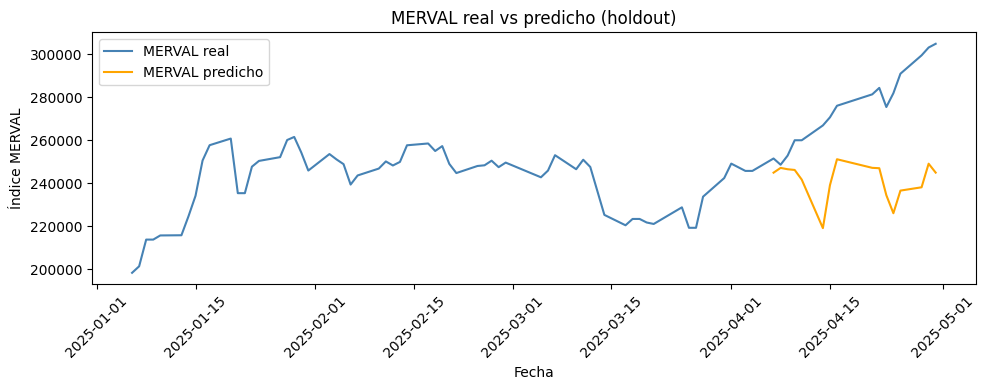

In [38]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


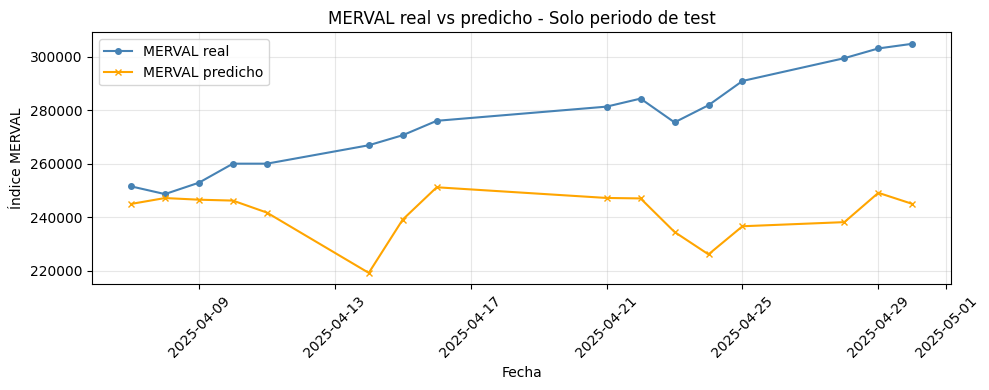

In [39]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

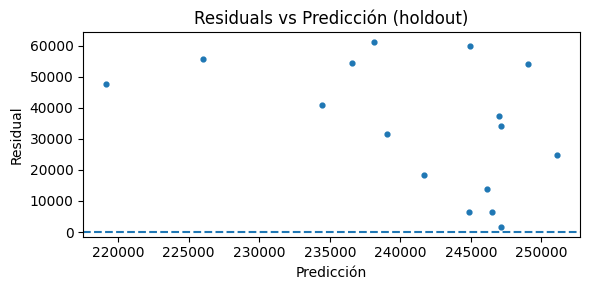

In [40]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


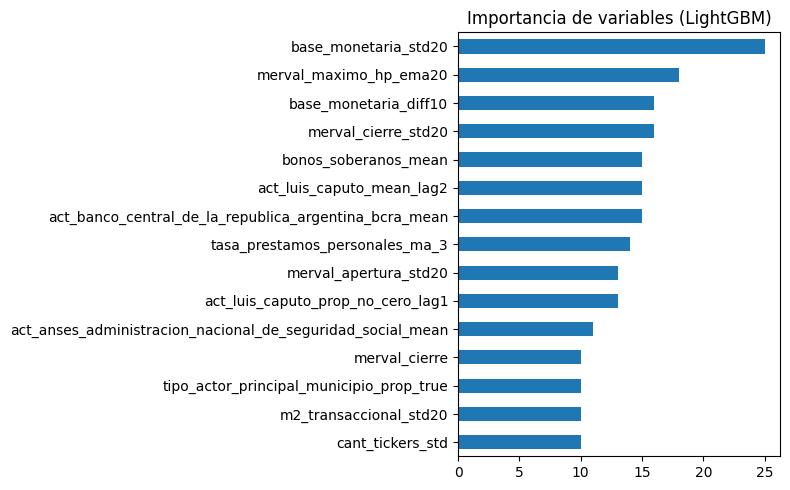

In [41]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
